In [1]:
# Here we are including some more clinical stores

C:\Users\Abhineet Anand\AppData\Local\Temp\ipykernel_26492\2366700347.py:12: DtypeWarning: Columns (19,20,21,50,51,104,105,106) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('adnimerge.csv')


Class distribution AFTER adding Strategy 1 features:
DX
MCI         4675
CN          3756
Dementia    2198
Name: count, dtype: int64

Training Strategy 1 Model...

--- Strategy 1 Model Evaluation ---
Accuracy Score: 0.8824082784571966

Classification Report:
               precision    recall  f1-score   support

          CN       0.93      0.90      0.92       751
    Dementia       0.87      0.83      0.85       440
         MCI       0.85      0.89      0.87       935

    accuracy                           0.88      2126
   macro avg       0.88      0.87      0.88      2126
weighted avg       0.88      0.88      0.88      2126



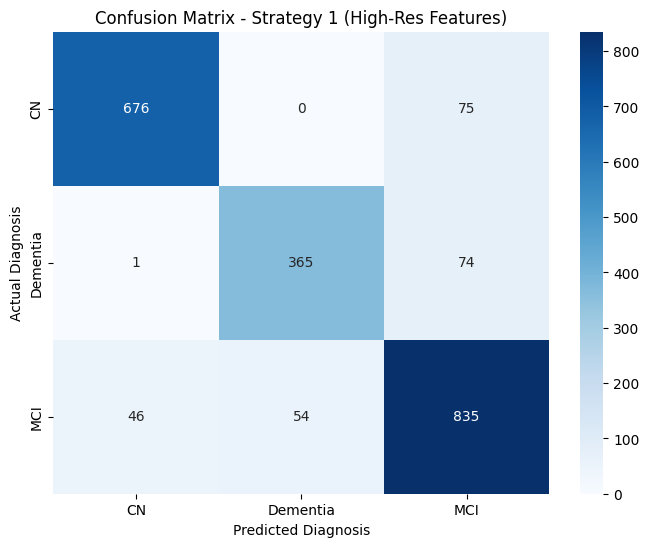

C:\Users\Abhineet Anand\AppData\Local\Temp\ipykernel_26492\2366700347.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_s1, palette='viridis')


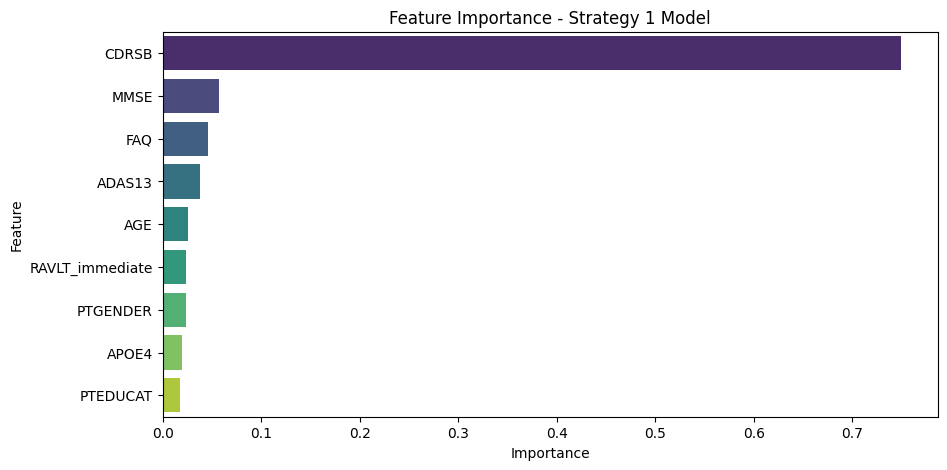

In [2]:
# Strategy 1: High-Resolution Clinical Features Model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('adnimerge.csv')
target_col = 'DX'

# 2. STRATEGY 1 IMPLEMENTATION: Add the "Cheat Code" Features
# We keep our demographics and APOE4, plus MMSE/CDRSB, 
# AND we add ADAS13, FAQ, and RAVLT_immediate.
strategy1_features = [
    'APOE4', 'AGE', 'PTGENDER', 'PTEDUCAT',  # Base non-invasive
    'MMSE', 'CDRSB',                         # Standard clinical
    'ADAS13', 'FAQ', 'RAVLT_immediate'       # <-- STRATEGY 1 ADDITIONS
]

# 3. Subset and Clean the Data
df_s1 = df[['RID', 'VISCODE', target_col] + strategy1_features].copy()

# Drop rows missing the target or ANY of our specific features
df_s1 = df_s1.dropna(subset=[target_col] + strategy1_features)

# Convert Gender to numeric (Male=0, Female=1)
df_s1['PTGENDER'] = df_s1['PTGENDER'].map({'Male': 0, 'Female': 1})

print("Class distribution AFTER adding Strategy 1 features:")
print(df_s1[target_col].value_counts())

# 4. Prepare X and y
X_s1 = df_s1[strategy1_features]
y_s1 = df_s1[target_col]

# XGBoost requires target variables to be purely numeric (0, 1, 2)
label_encoder_s1 = LabelEncoder()
y_s1_encoded = label_encoder_s1.fit_transform(y_s1)

# 5. Train-Test Split (Stratified)
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1_encoded, test_size=0.20, random_state=42, stratify=y_s1_encoded
)

# 6. Feature Scaling
scaler_s1 = StandardScaler()
X_train_scaled_s1 = scaler_s1.fit_transform(X_train_s1)
X_test_scaled_s1 = scaler_s1.transform(X_test_s1)

# 7. Initialize and Train XGBoost Model
xgb_s1 = XGBClassifier(
    n_estimators=200, 
    max_depth=4,               
    learning_rate=0.05, 
    subsample=0.8,             
    eval_metric='mlogloss',
    random_state=42
)

print("\nTraining Strategy 1 Model...")
xgb_s1.fit(X_train_scaled_s1, y_train_s1)

# 8. Predict on Unseen Test Data
y_pred_encoded_s1 = xgb_s1.predict(X_test_scaled_s1)

# Convert predictions back to text (CN, MCI, Dementia)
y_pred_text_s1 = label_encoder_s1.inverse_transform(y_pred_encoded_s1)
y_test_text_s1 = label_encoder_s1.inverse_transform(y_test_s1)

# 9. Final Evaluation Metrics
print("\n--- Strategy 1 Model Evaluation ---")
print("Accuracy Score:", accuracy_score(y_test_text_s1, y_pred_text_s1))
print("\nClassification Report:\n", classification_report(y_test_text_s1, y_pred_text_s1))

# 10. Visualizations
# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_s1 = confusion_matrix(y_test_text_s1, y_pred_text_s1, labels=label_encoder_s1.classes_)
sns.heatmap(cm_s1, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder_s1.classes_, 
            yticklabels=label_encoder_s1.classes_)
plt.title('Confusion Matrix - Strategy 1 (High-Res Features)')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

# Plot Feature Importance
feature_importances_s1 = xgb_s1.feature_importances_
importance_df_s1 = pd.DataFrame({
    'Feature': strategy1_features,
    'Importance': feature_importances_s1
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df_s1, palette='viridis')
plt.title('Feature Importance - Strategy 1 Model')
plt.show()